In [175]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [176]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("bmh")

In [177]:
df = pd.read_csv('Churn_Modelling.csv')

In [178]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [179]:
df.shape

(10000, 14)

In [180]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [181]:
df = df.drop(columns=['RowNumber'])



In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [183]:
df.isnull().sum()          # nulos por coluna

,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0


In [184]:
df.duplicated().sum()      # linhas duplicadas


np.int64(0)

In [185]:
df['CustomerId'].nunique() # IDs únicos — deve bater com o total de linhas

10000

In [186]:
df[['CustomerId', 'Surname', 'Geography', 'Exited']] # Pegando as 4 colunas para a análise

,CustomerId,Surname,Geography,Exited
0,15634602,Hargrave,France,1
1,15647311,Hill,Spain,0
2,15619304,Onio,France,1
3,15701354,Boni,France,0
4,15737888,Mitchell,Spain,0
...,...,...,...,...
9995,15606229,Obijiaku,France,0
9996,15569892,Johnstone,France,0
9997,15584532,Liu,France,1
9998,15682355,Sabbatini,Germany,1


In [187]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [188]:
(df.groupby(['Geography'])['Exited'].value_counts(normalize=True)*100).round(2)
# (df.groupby(['Geography'])['Exited'].value_counts(normalize=True)*100).round(2).astype(str) + '%'

Geography  Exited
France     0         83.85
           1         16.15
Germany    0         67.56
           1         32.44
Spain      0         83.33
           1         16.67
Name: proportion, dtype: float64

In [189]:
(df.groupby(['Exited'])['Geography'].value_counts(normalize=True)*100).round(2)

Exited  Geography
0       France       52.79
        Spain        25.92
        Germany      21.29
1       Germany      39.96
        France       39.76
        Spain        20.27
Name: proportion, dtype: float64

In [190]:
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [191]:
df['CreditScore'].describe() # Resumir estatisticamente os dados da coluna CreditScore

,CreditScore
count,10000.000000
mean,650.528800
std,96.653299
min,350.000000
25%,584.000000
50%,652.000000
75%,718.000000
max,850.000000


In [192]:
df["Geography"].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [193]:
df["Gender"].value_counts()

,count
Gender,
Male,5457
Female,4543


In [194]:
df['Age'].describe()

,Age
count,10000.000000
mean,38.921800
std,10.487806
min,18.000000
25%,32.000000
50%,37.000000
75%,44.000000
max,92.000000


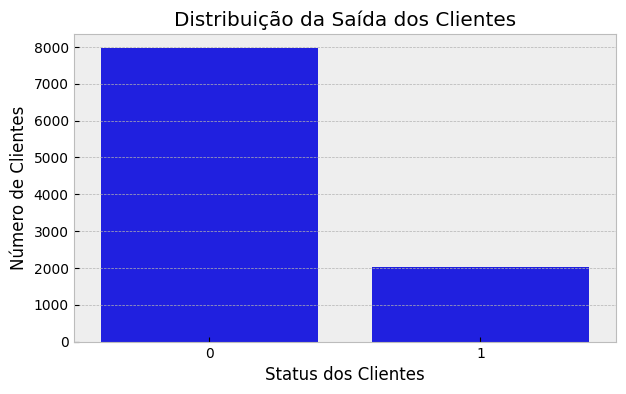

In [195]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Exited',color='blue')
plt.xlabel('Status dos Clientes')
plt.ylabel('Número de Clientes')
plt.title('Distribuição da Saída dos Clientes')
plt.show()

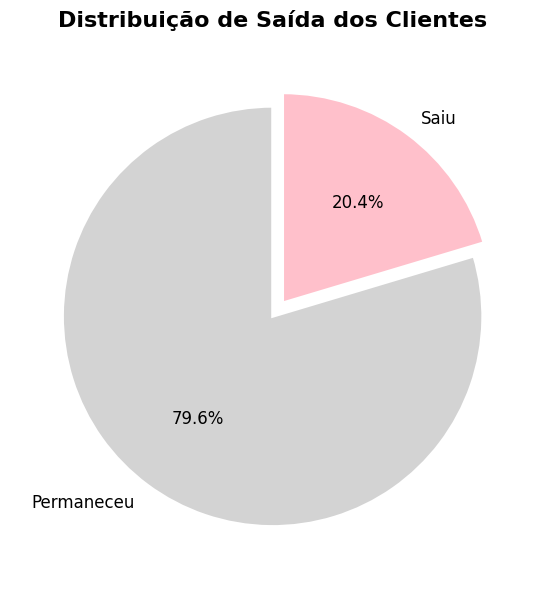

In [196]:
plt.figure(figsize=(7, 6))

df['Exited'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    explode=[0, 0.08],
    colors=['lightgray', 'pink'],
    labels=['Permaneceu', 'Saiu'],
    startangle=90,
    textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.ylabel('')
plt.title(
    'Distribuição de Saída dos Clientes',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

In [197]:
(df["Exited"].value_counts(normalize=True)*100).round(1) # Conferir se os sumeros estao batendo

,proportion
Exited,
0,79.6
1,20.4


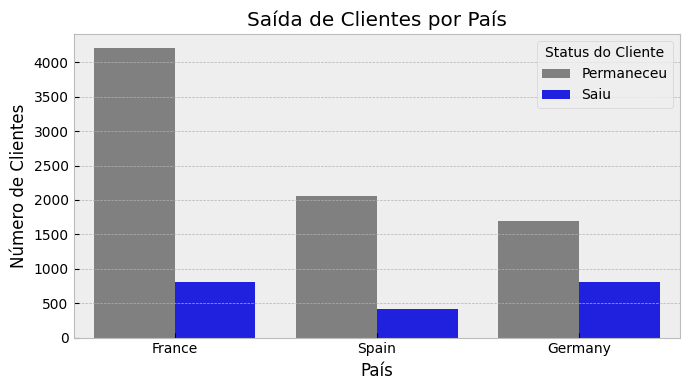

In [198]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=df,
    x='Geography',
    hue='Exited',
    palette=['gray', 'blue']
)

plt.xlabel('País')
plt.ylabel('Número de Clientes')
plt.title('Saída de Clientes por País')

plt.legend(
    title='Status do Cliente',
    labels=['Permaneceu', 'Saiu']
)

plt.tight_layout()
plt.show()

In [199]:
df.groupby('Geography')['Exited'].mean()*100


,Exited
Geography,
France,16.154767
Germany,32.443204
Spain,16.673395


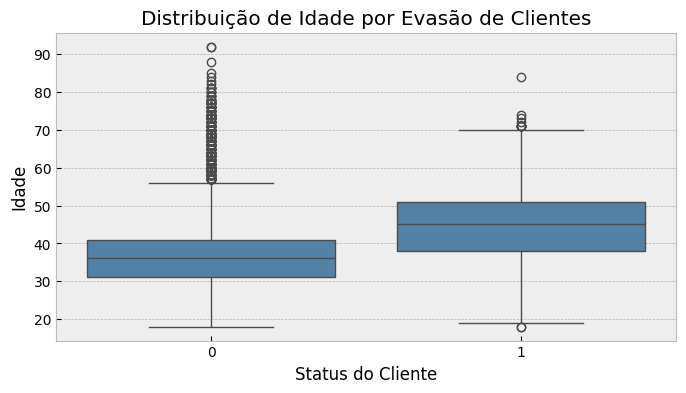

In [200]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Exited', y='Age', color='steelblue')
plt.xlabel('Status do Cliente')
plt.ylabel('Idade')
plt.title('Distribuição de Idade por Evasão de Clientes')
plt.show()

In [201]:
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


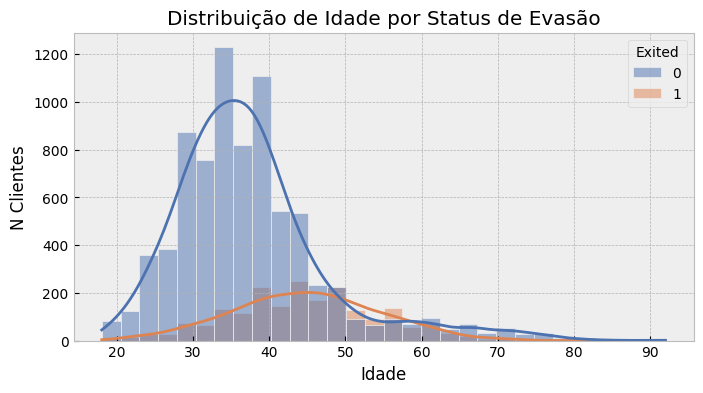

In [202]:
PALETA = ['#4C72B0', '#DD8452']
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Age', hue='Exited', bins=30, kde=True, palette=PALETA)
plt.xlabel('Idade')
plt.ylabel('N Clientes')
plt.title('Distribuição de Idade por Status de Evasão')
plt.show()

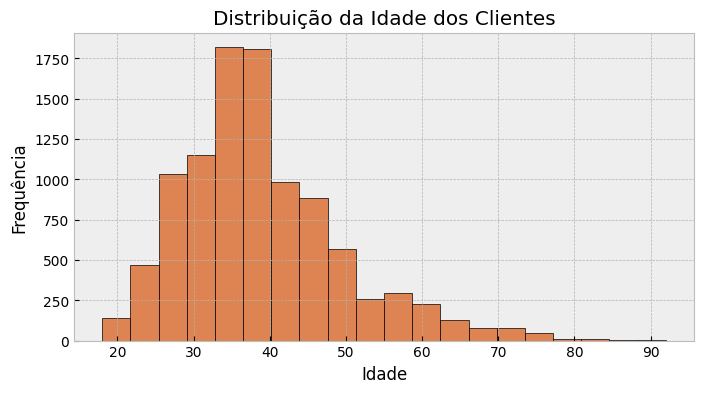

In [203]:
PALETA = ['#4C72B0', '#DD8452']

plt.figure(figsize=(8, 4))

plt.hist(
    df['Age'],
    bins=20,
    edgecolor='black',
    color=PALETA[1]
)

plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.title('Distribuição da Idade dos Clientes')

plt.show()

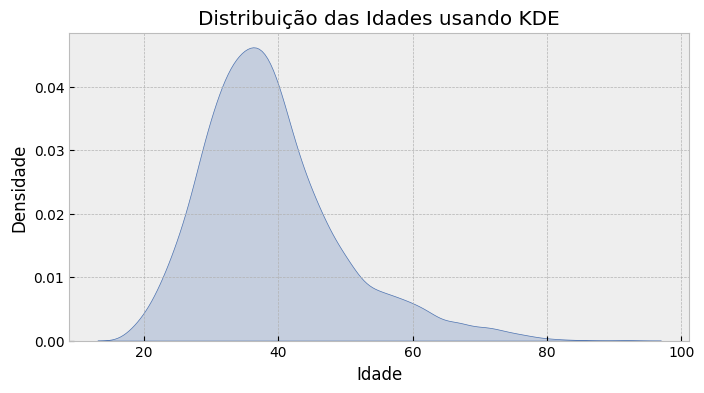

In [204]:
PALETA = ['#4C72B0', '#DD8452']
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x='Age', fill=True,color=PALETA[0])
plt.xlabel('Idade')
plt.ylabel('Densidade')
plt.title('Distribuição das Idades usando KDE')
plt.show()

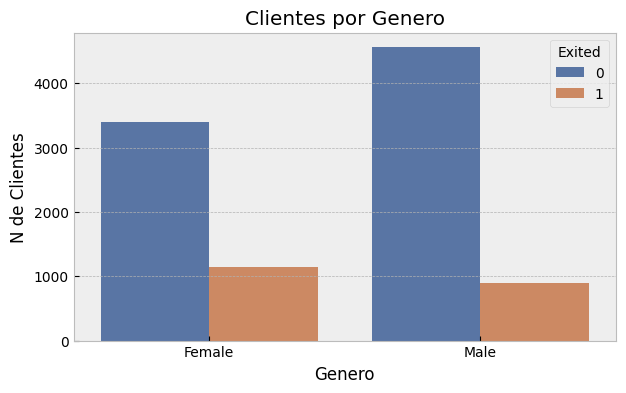

In [205]:
PALETA = ['#4C72B0', '#DD8452']
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Gender', hue= 'Exited',palette=[PALETA[0], PALETA[1]])
plt.xlabel('Genero')
plt.ylabel('N de Clientes')
plt.title('Clientes por Genero')
plt.show()

In [206]:
df.groupby('Gender')['Exited'].mean()*100

,Exited
Gender,
Female,25.071539
Male,16.455928


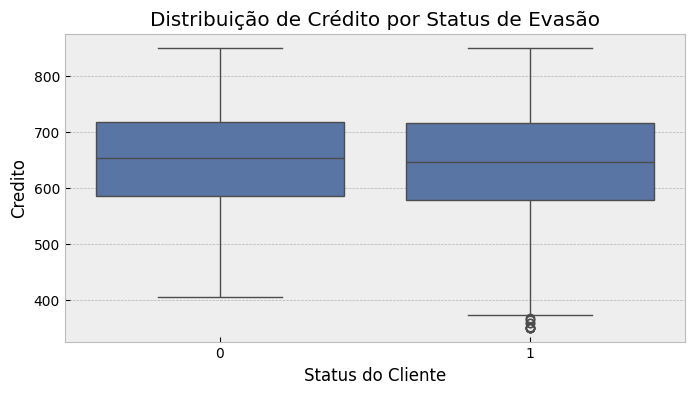

In [207]:
PALETA = ['#4C72B0', '#DD8452']
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Exited', y='CreditScore', color=PALETA[0])
plt.xlabel('Status do Cliente')
plt.ylabel('Credito')
plt.title('Distribuição de Crédito por Status de Evasão')
plt.show()

Text(0.5, 1.0, 'Distribuição de Crédito por Status de Evasão')

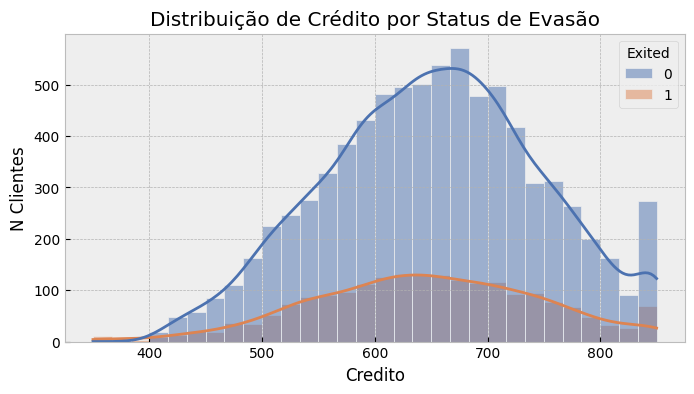

In [208]:
PALETA = ['#4C72B0', '#DD8452']
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='CreditScore', hue='Exited',bins=30, kde=True, palette=PALETA)
plt.xlabel('Credito')
plt.ylabel('N Clientes')
plt.title('Distribuição de Crédito por Status de Evasão')


In [209]:
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


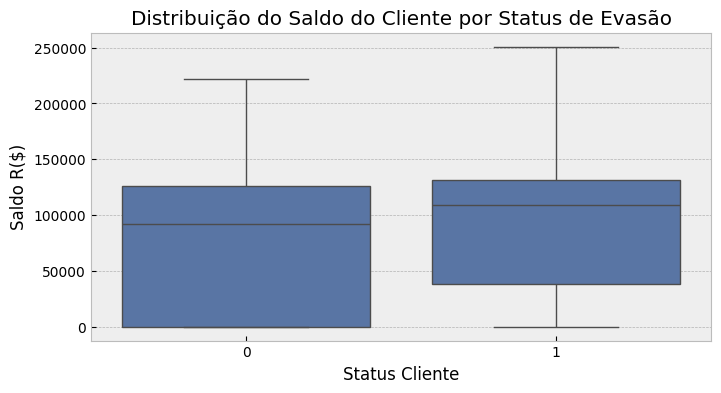

In [210]:
PALETA = ['#4C72B0', '#DD8452']
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Exited', y='Balance', color=PALETA[0])
plt.xlabel('Status Cliente')
plt.ylabel('Saldo R($)')
plt.title('Distribuição do Saldo do Cliente por Status de Evasão')
plt.show()

In [211]:
df.groupby('Exited')['Balance'].describe()

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,7963.0,72745.296779,62848.040701,0.0,0.00,92072.68,126410.28,221532.80
1,2037.0,91108.539337,58360.794816,0.0,38340.02,109349.29,131433.33,250898.09


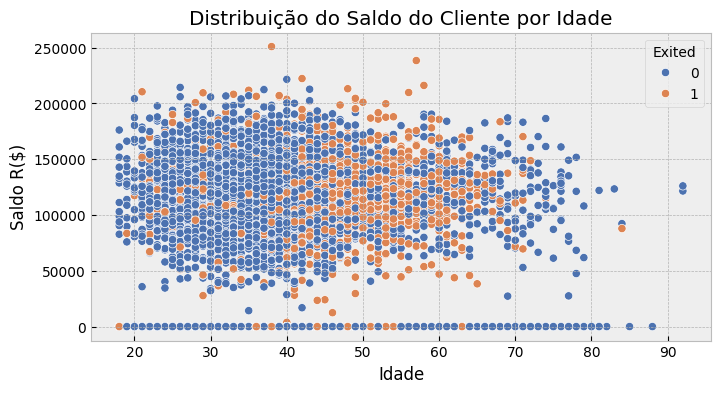

In [212]:
PALETA = ['#4C72B0', '#DD8452']
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='Age', y='Balance', hue='Exited', palette=PALETA)
plt.xlabel('Idade')
plt.ylabel('Saldo R($)')
plt.title('Distribuição do Saldo do Cliente por Idade')
plt.show()

In [213]:
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


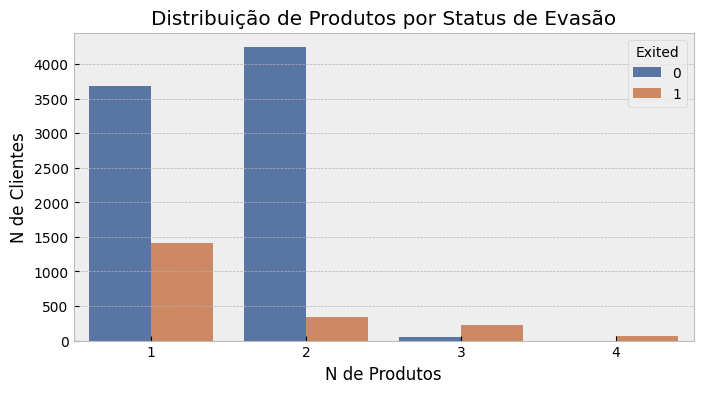

In [214]:
PALETA = ['#4C72B0', '#DD8452']
plt.figure(figsize=(8, 4))
sns.countplot(data=df,x='NumOfProducts', hue='Exited', palette = [PALETA[0], PALETA[1]])
plt.xlabel('N de Produtos')
plt.ylabel('N de Clientes')
plt.title('Distribuição de Produtos por Status de Evasão')
plt.show()


In [215]:
df.groupby('NumOfProducts')['Exited'].mean()*100

,Exited
NumOfProducts,
1,27.714398
2,7.581699
3,82.706767
4,100.000000


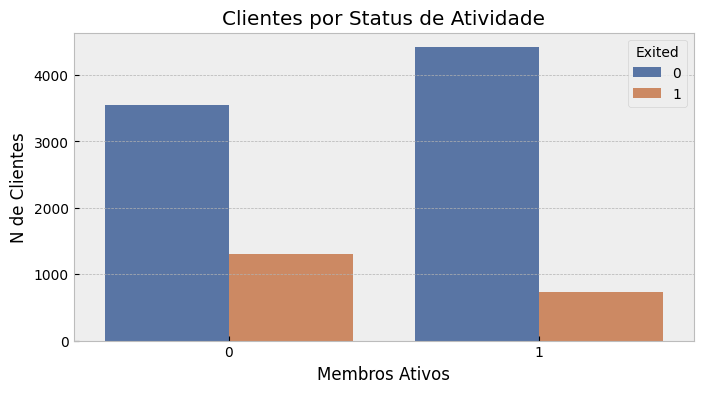

In [216]:
PALETA = ['#4C72B0', '#DD8452']
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='IsActiveMember', hue='Exited',palette = [PALETA[0], PALETA[1]])
plt.xlabel('Membros Ativos')
plt.ylabel('N de Clientes')
plt.title('Clientes por Status de Atividade')
plt.show()

In [217]:
df['IsActiveMember'].value_counts()

,count
IsActiveMember,
1,5151
0,4849


In [218]:
df.groupby('IsActiveMember')['Exited'].mean()*100

,Exited
IsActiveMember,
0,26.850897
1,14.269074


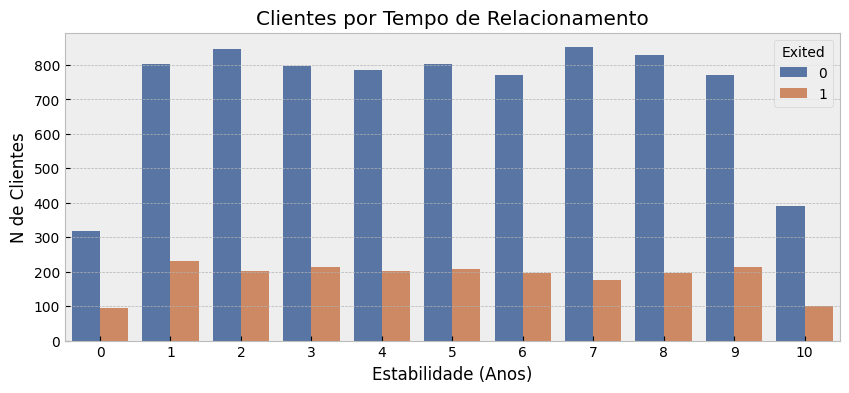

In [219]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='Tenure', hue='Exited',palette = [PALETA[0], PALETA[1]])
plt.xlabel('Estabilidade (Anos)')
plt.ylabel('N de Clientes')
plt.title('Clientes por Tempo de Relacionamento')
plt.show()

In [220]:
df.groupby('Tenure')['Exited'].mean()*100

,Exited
Tenure,
0,23.002421
1,22.415459
2,19.179389
3,21.110010
4,20.525784
5,20.652174
6,20.268873
7,17.217899
8,19.219512


In [221]:
df.groupby('Tenure')['Exited'].describe()

,count,mean,std,min,25%,50%,75%,max
Tenure,,,,,,,,
0,413.0,0.230024,0.421358,0.0,0.0,0.0,0.0,1.0
1,1035.0,0.224155,0.417226,0.0,0.0,0.0,0.0,1.0
2,1048.0,0.191794,0.393900,0.0,0.0,0.0,0.0,1.0
3,1009.0,0.211100,0.408292,0.0,0.0,0.0,0.0,1.0
4,989.0,0.205258,0.404094,0.0,0.0,0.0,0.0,1.0
5,1012.0,0.206522,0.405009,0.0,0.0,0.0,0.0,1.0
6,967.0,0.202689,0.402211,0.0,0.0,0.0,0.0,1.0
7,1028.0,0.172179,0.377720,0.0,0.0,0.0,0.0,1.0
8,1025.0,0.192195,0.394218,0.0,0.0,0.0,0.0,1.0


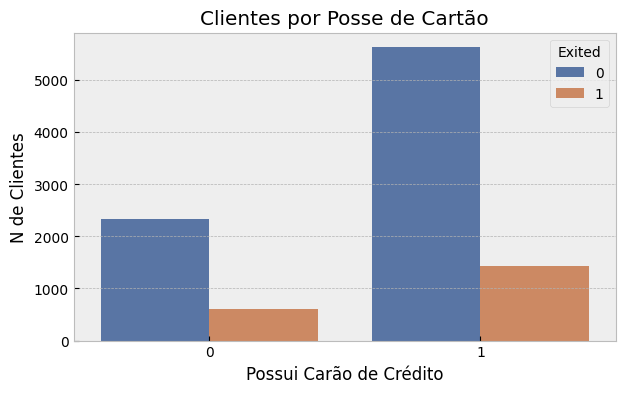

In [222]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='HasCrCard', hue='Exited',palette = [PALETA[0], PALETA[1]])
plt.xlabel('Possui Carão de Crédito')
plt.ylabel('N de Clientes')
plt.title('Clientes por Posse de Cartão')
plt.show()

In [223]:
df.groupby('HasCrCard')['Exited'].mean()*100

,Exited
HasCrCard,
0,20.814941
1,20.184266


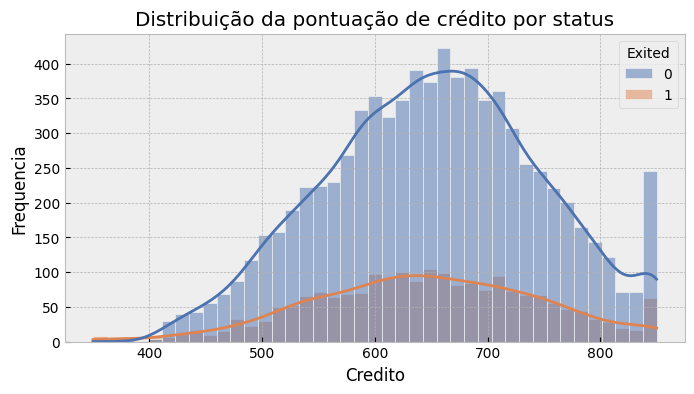

In [224]:
PALETA = ['#4C72B0', '#DD8452']
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='CreditScore', hue='Exited', kde=True, palette=PALETA)
plt.xlabel('Credito')
plt.ylabel('Frequencia')
plt.title('Distribuição da pontuação de crédito por status')
plt.show()


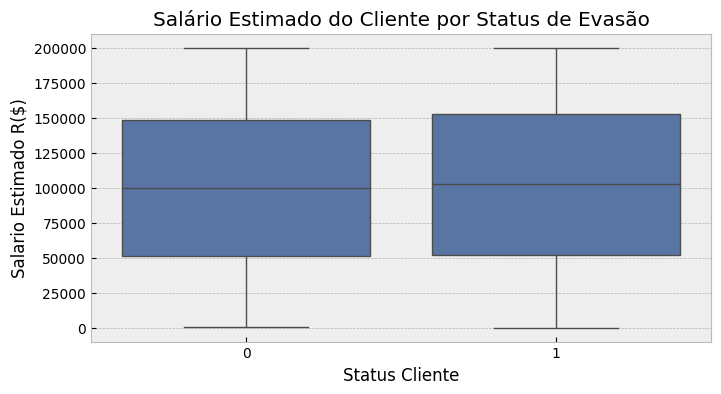

In [225]:
PALETA = ['#4C72B0', '#DD8452']
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Exited', y='EstimatedSalary', color=PALETA[0])
plt.xlabel('Status Cliente')
plt.ylabel('Salario Estimado R($)')
plt.title('Salário Estimado do Cliente por Status de Evasão')
plt.show()

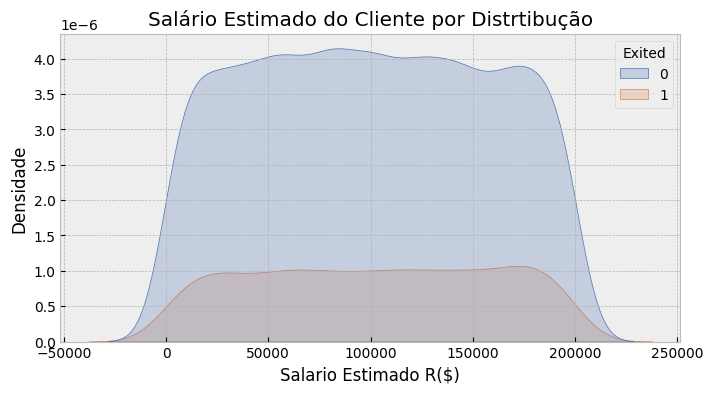

In [226]:
PALETA = ['#4C72B0', '#DD8452']
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x='EstimatedSalary', hue='Exited',fill=True, palette=[PALETA[0], PALETA[1]])
plt.xlabel('Salario Estimado R($)')
plt.ylabel('Densidade')
plt.title('Salário Estimado do Cliente por Distrtibução')
plt.show()

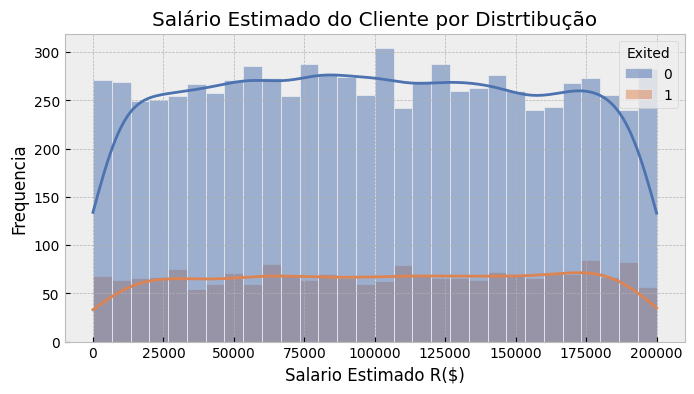

In [227]:
PALETA = ['#4C72B0', '#DD8452']
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='EstimatedSalary', hue='Exited',fill=True,bins=30,kde=True, palette=[PALETA[0], PALETA[1]])
plt.xlabel('Salario Estimado R($)')
plt.ylabel('Frequencia')
plt.title('Salário Estimado do Cliente por Distrtibução')
plt.show()

In [228]:
bins   = [18, 31, 41, 51, 61, float('inf')]
labels = ['18-30', '31-40', '41-50', '51-60', '61+']

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    right=False,      # intervalos [18,31), [31,41), ... — fecha à esquerda
    ordered=True,     # permite comparações e ordena bem em groupby/plots
)

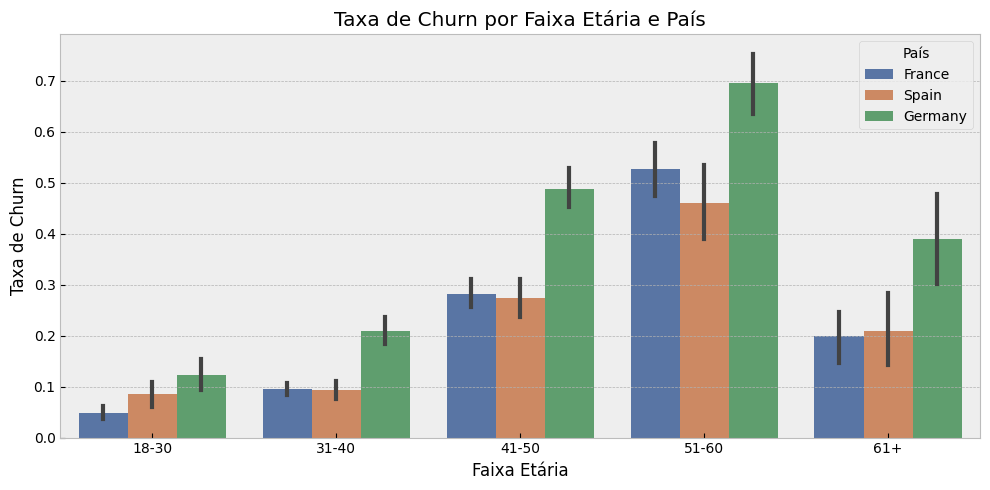

In [229]:
PALETA = ['#4C72B0', '#DD8452', '#55A868']

plt.figure(figsize=(10, 5))
sns.barplot(
    data=df,
    x='AgeGroup',
    y='Exited',
    hue='Geography',
    palette=PALETA,
)
plt.xlabel('Faixa Etária')
plt.ylabel('Taxa de Churn')
plt.title('Taxa de Churn por Faixa Etária e País')
plt.legend(title='País')
plt.tight_layout()
plt.show()